# Import The Necessary Libraries

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.metrics import roc_curve,auc
from sklearn.neighbors import KNeighborsClassifier


# Dataset

In [10]:
df = pd.read_csv('C:\\AI - Field\\Ds_Bootcamp\\Ds_3rdweek\\Titanic-Dataset.csv')
missig_values = df.isnull().sum()
print(missig_values)


PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64


# Pre-Processing

In [11]:
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.mean()))
df['Fare'] = df.groupby(['Pclass', 'Sex'])['Fare'].transform(lambda x: x.fillna(x.mean()))
df['Has_Cabin'] = df['Cabin'].notna().astype(int)
df.drop('Cabin',axis=1,inplace=True)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# One-Hot Encoding or Label Encoding Process

In [12]:
#Drop The Unnecessary Columns
df.drop('Ticket',axis=1,inplace=True)
df.drop('PassengerId',axis=1,inplace=True)

#Use the Label-Encoding
df.replace({'Sex':{'male':0,'female':1}},inplace=True)

#Use One-Hot-Encoding
df['Embarked_S'] = df['Embarked'].apply(lambda x: 1 if x == 'S' else 0)
df['Embarked_C'] = df['Embarked'].apply(lambda x: 1 if x == 'C' else 0)
df['Embarked_Q'] = df['Embarked'].apply(lambda x: 1 if x=='Q' else 0)
df.drop('Embarked',axis=1,inplace=True)

#Use One-Hot-Encoding
pclass_dummies = pd.get_dummies(df['Pclass'], prefix='Pclass', drop_first=True).astype(int)
df = pd.concat([df, pclass_dummies], axis=1)
df.drop('Pclass', axis=1, inplace=True)


C:\Users\javad\AppData\Local\Temp\ipykernel_8756\1985792612.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Sex':{'male':0,'female':1}},inplace=True)


## Feature Engineering

In [13]:
df['FamilySize'] = ((df['SibSp'] + df['Parch'])>0).astype(int)
df['IsAlone'] = (df['FamilySize'] == 0).astype(int)

df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].apply(lambda x: x if x in ['Mr', 'Mrs', 'Miss'] else 'Other')


title_dummies = pd.get_dummies(df['Title'], prefix='Title', drop_first=True).astype(int)
df = pd.concat([df, title_dummies], axis=1)


df['Age'] = pd.cut(df['Age'], bins=[0,12,60,100],labels=['Child','Adult','Elderly'])

age_dummies = pd.get_dummies(df['Age'], prefix='Age', drop_first=True).astype(int)
df = pd.concat([df, age_dummies], axis=1)


df.drop(['SibSp','Parch','Title','Name','Age',],axis=1,inplace=True)

scaler = MinMaxScaler()
df[['Fare']] = scaler.fit_transform(df[['Fare']])

# Train,Validation,Test  Split

In [14]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.15,
                                                    random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train,
                                                  y_train,
                                                  test_size=0.1764
                                                  , random_state=42)

# Model Training

In [15]:
model = LogisticRegression(
         penalty='l1',
         C=0.5,
         solver='liblinear',
         max_iter=100)

model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)

validation_score = model.score(X_val, y_val)

test_score = model.predict(X_test)


print("Train Score",train_score)
print("Validation Score",validation_score)
print('accuracy_score',accuracy_score(y_test,test_score))
print('classification_score',classification_report(y_test,test_score))


Train Score 0.8622950819672132
Validation Score 0.8477157360406091
accuracy_score 0.8375634517766497
classification_score               precision    recall  f1-score   support

           0       0.84      0.90      0.87       115
           1       0.84      0.76      0.79        82

    accuracy                           0.84       197
   macro avg       0.84      0.83      0.83       197
weighted avg       0.84      0.84      0.84       197



C:\Users\javad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\javad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


# Confusion Matrix

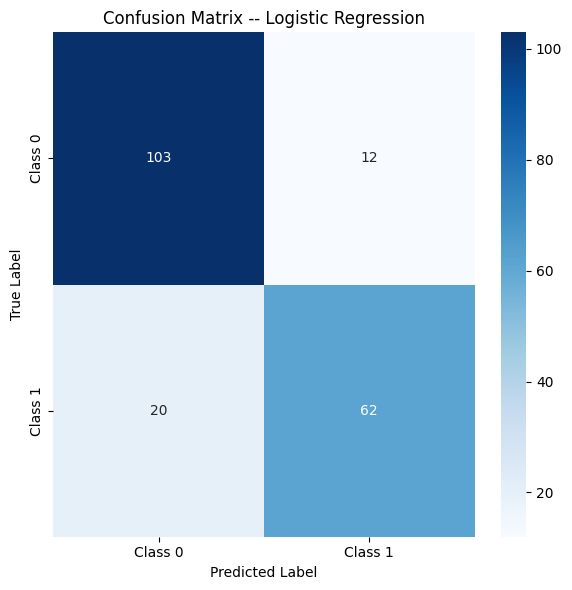

In [16]:
cm = confusion_matrix(y_test,test_score)


plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix -- Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

# ROC & AUC Calculation

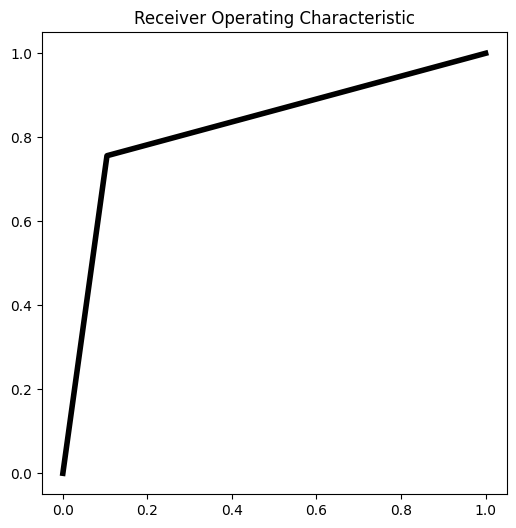

In [17]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, test_score,pos_label=1)
roc_auc = metrics.auc(fpr, tpr)
plt.figure(figsize=(6, 6))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, color='black', lw=4, label='ROC curve (area = %0.2f)' % roc_auc)


# Five-Most Principals

In [18]:
feature_names = X_train.columns
feature_Importance = pd.DataFrame({'Feature': feature_names,'Importance': model.coef_[0]})

feature_Importance.sort_values(by='Importance',ascending=False,inplace=True)
print(feature_Importance.head(5))

       Feature  Importance
0          Sex    2.092868
2    Has_Cabin    0.687982
11   Title_Mrs    0.409438
4   Embarked_C    0.000000
5   Embarked_Q    0.000000


# k-Nearest Neighbors (k-NN)

In [19]:
neighbors = KNeighborsClassifier(n_neighbors=5)

neighbors.fit(X_train,y_train)

train_score = neighbors.score(X_train,y_train)

validation_score = neighbors.score(X_val,y_val)


test_score = neighbors.predict(X_test)
test_accuracy =accuracy_score(y_test,test_score)

print('train_score',train_score)
print('validation_score',validation_score)
print('test_score',test_accuracy)





train_score 0.8852459016393442
validation_score 0.8274111675126904
test_score 0.8578680203045685
